# EDA

## Load data

In [1]:
import pandas as pd 

df = pd.read_csv("../data/simulated/hourly_energy_data.csv")
df.head()

,timestamp,electricity_price,temperature,production_load,historical_energy_usage
0,2026-01-01T00:00,0.915,-3.8,low,121.37
1,2026-01-01T01:00,0.977,-4.9,low,112.75
2,2026-01-01T02:00,0.917,-3.5,low,117.48
3,2026-01-01T03:00,0.937,-2.8,medium,150.58
4,2026-01-01T04:00,0.982,-1.2,medium,148.06


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                2160 non-null   str    
 1   electricity_price        2160 non-null   float64
 2   temperature              2160 non-null   float64
 3   production_load          2160 non-null   str    
 4   historical_energy_usage  2160 non-null   float64
dtypes: float64(3), str(2)
memory usage: 128.1 KB


In [3]:
df.shape

(2160, 5)

In [4]:
df.describe()

,electricity_price,temperature,historical_energy_usage
count,2160.000000,2160.000000,2160.000000
mean,1.045734,5.176898,137.183343
std,0.192257,4.228804,26.848081
min,0.639000,-5.100000,70.370000
25%,0.901000,2.100000,118.000000
50%,1.008000,5.300000,135.750000
75%,1.204000,8.300000,156.075000
max,1.526000,16.200000,207.080000


### Convert timestamp

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df.head()

,timestamp,electricity_price,temperature,production_load,historical_energy_usage
0,2026-01-01 00:00:00,0.915,-3.8,low,121.37
1,2026-01-01 01:00:00,0.977,-4.9,low,112.75
2,2026-01-01 02:00:00,0.917,-3.5,low,117.48
3,2026-01-01 03:00:00,0.937,-2.8,medium,150.58
4,2026-01-01 04:00:00,0.982,-1.2,medium,148.06


### Create time columns

In [6]:
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

df.head()

,timestamp,electricity_price,temperature,production_load,historical_energy_usage,date,hour,day_of_week
0,2026-01-01 00:00:00,0.915,-3.8,low,121.37,2026-01-01,0,Thursday
1,2026-01-01 01:00:00,0.977,-4.9,low,112.75,2026-01-01,1,Thursday
2,2026-01-01 02:00:00,0.917,-3.5,low,117.48,2026-01-01,2,Thursday
3,2026-01-01 03:00:00,0.937,-2.8,medium,150.58,2026-01-01,3,Thursday
4,2026-01-01 04:00:00,0.982,-1.2,medium,148.06,2026-01-01,4,Thursday


### Show data

In [7]:
df.sample(10)

,timestamp,electricity_price,temperature,production_load,historical_energy_usage,date,hour,day_of_week
893,2026-02-07 05:00:00,0.916,-0.0,low,107.03,2026-02-07,5,Saturday
280,2026-01-12 16:00:00,1.224,0.4,high,189.37,2026-01-12,16,Monday
83,2026-01-04 11:00:00,0.877,4.5,high,189.18,2026-01-04,11,Sunday
1754,2026-03-15 02:00:00,0.803,6.4,medium,108.62,2026-03-15,2,Sunday
230,2026-01-10 14:00:00,0.712,1.7,medium,165.27,2026-01-10,14,Saturday
1150,2026-02-17 22:00:00,1.016,3.2,medium,152.39,2026-02-17,22,Tuesday
874,2026-02-06 10:00:00,1.079,6.1,medium,145.66,2026-02-06,10,Friday
1568,2026-03-07 08:00:00,1.165,9.3,medium,136.78,2026-03-07,8,Saturday
2146,2026-03-31 10:00:00,1.080,12.9,medium,120.27,2026-03-31,10,Tuesday
88,2026-01-04 16:00:00,1.086,1.9,high,196.68,2026-01-04,16,Sunday


In [8]:
df.isna().sum()

timestamp                  0
electricity_price          0
temperature                0
production_load            0
historical_energy_usage    0
date                       0
hour                       0
day_of_week                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Price over the day

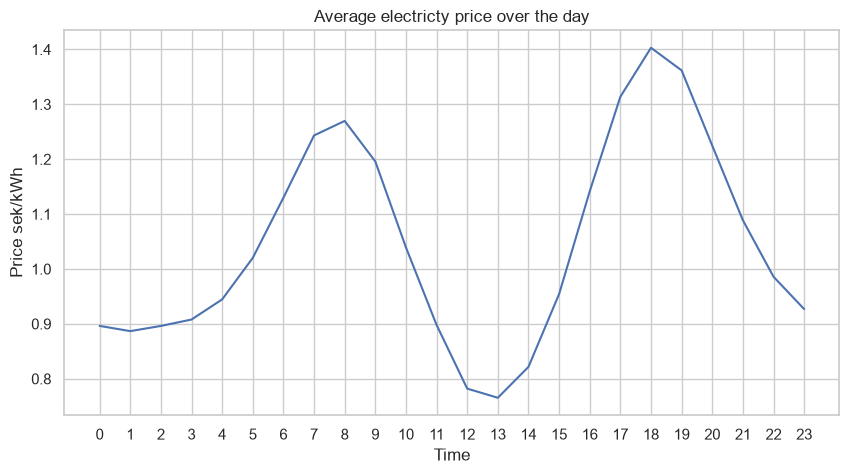

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="hour",
    y="electricity_price",
    estimator="mean",
    errorbar=None
)

plt.title("Average electricty price over the day")
plt.xlabel("Time")
plt.ylabel("Price sek/kWh")
plt.xticks(range(0, 24))
plt.show()


### Electricity price over time

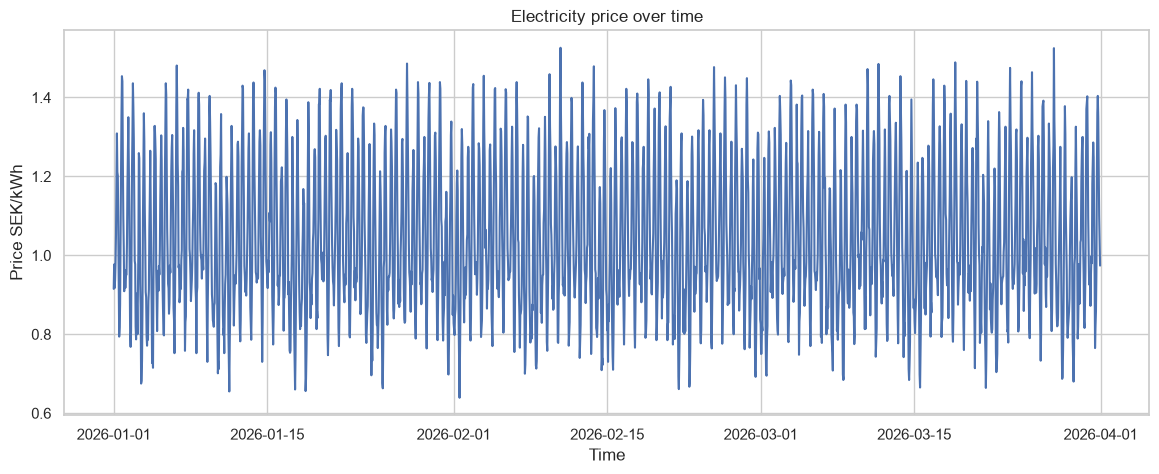

In [12]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=df,
    x="timestamp",
    y="electricity_price"
)

plt.title("Electricity price over time")
plt.xlabel("Time")
plt.ylabel("Price SEK/kWh")
plt.show()

### Energy consumption over time

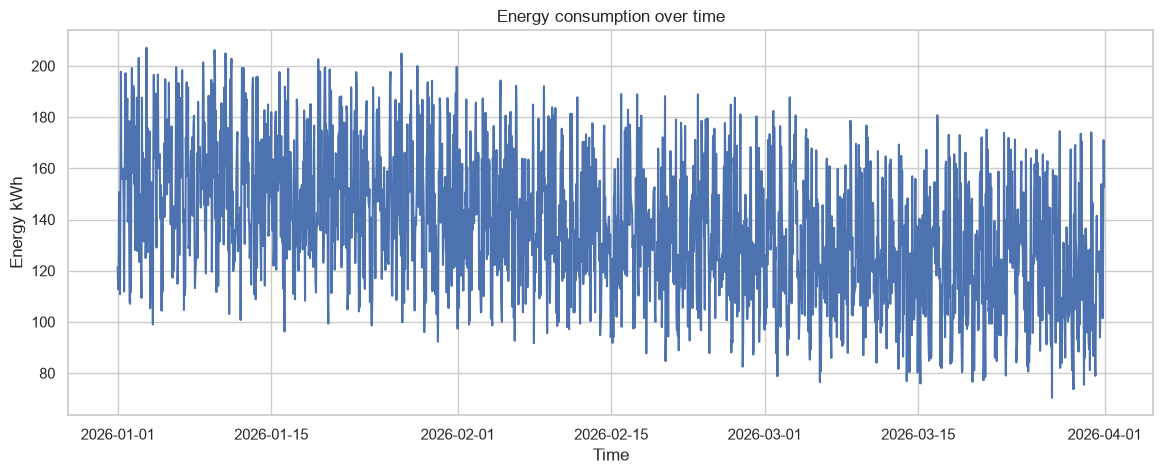

In [13]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=df,
    x="timestamp",
    y="historical_energy_usage"
)

plt.title("Energy consumption over time")
plt.xlabel("Time")
plt.ylabel("Energy kWh")
plt.show()

### Temperature over time

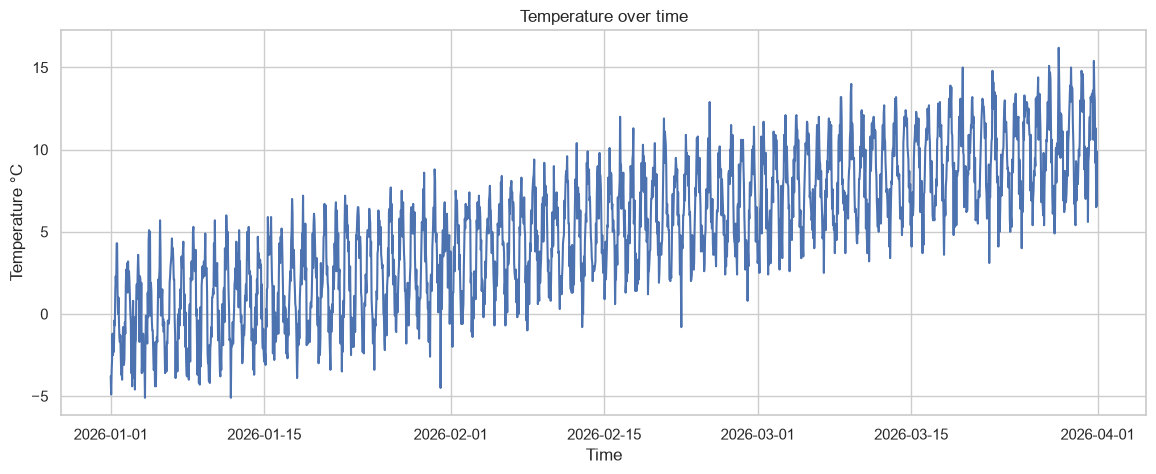

In [17]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=df,
    x="timestamp",
    y="temperature"
)

plt.title("Temperature over time")
plt.xlabel("Time")
plt.ylabel("Temperature °C")
plt.show()

### Comparisson: Temperature vs historical energy usage

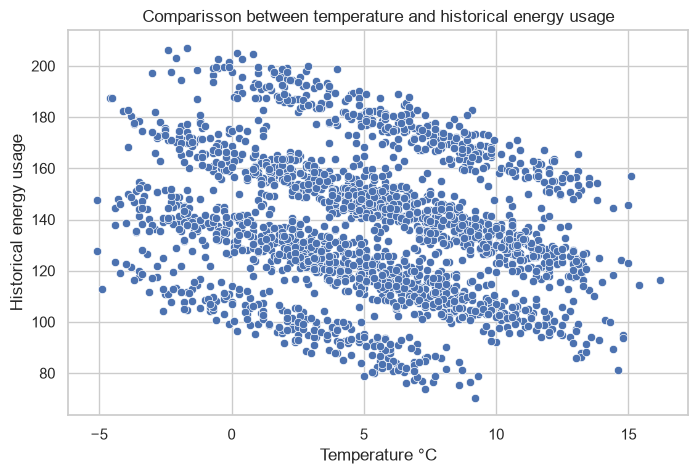

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="historical_energy_usage"
)

plt.title("Comparisson between temperature and historical energy usage")
plt.xlabel("Temperature °C")
plt.ylabel("Historical energy usage")
plt.show()

### Comparison: production load and energy consumption

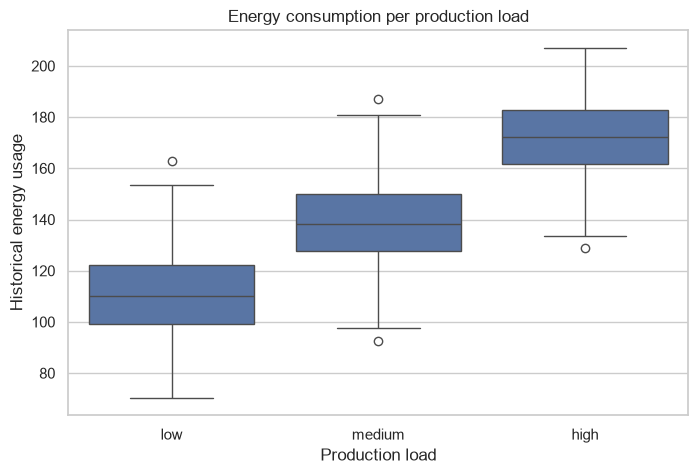

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="production_load",
    y="historical_energy_usage",
    order=["low", "medium", "high"]
)

plt.title("Energy consumption per production load")
plt.xlabel("Production load")
plt.ylabel("Historical energy usage")
plt.show()

### Comparison: Temperature, production load and energy

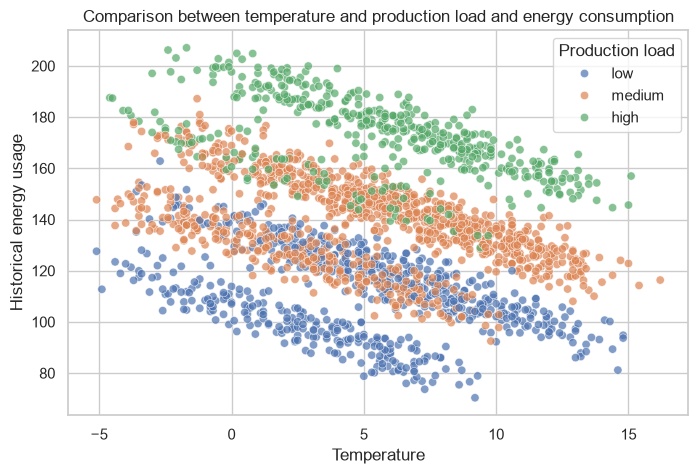

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="historical_energy_usage",
    hue="production_load",
    hue_order=["low", "medium", "high"],
    alpha=0.7
)

plt.title("Comparison between temperature and production load and energy consumption")
plt.xlabel("Temperature")
plt.ylabel("Historical energy usage")
plt.legend(title="Production load")
plt.show()

### Electricity price and energy consumption

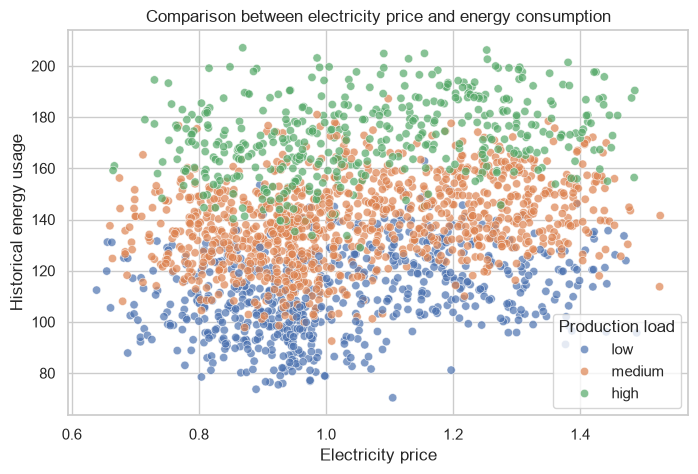

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="electricity_price",
    y="historical_energy_usage",
    hue="production_load",
    hue_order=["low", "medium", "high"],
    alpha=0.7
)

plt.title("Comparison between electricity price and energy consumption")
plt.xlabel("Electricity price")
plt.ylabel("Historical energy usage")
plt.legend(title="Production load")
plt.show()